# Model Development with Python and Software Packages
## Module 5(1) - Classification Modeling (Tree-based)
### MBA Admission Prediction with a Decision Tree
Asst. Prof. Dr. Santitham Prom-on

This notebook uses a decision tree to predict whether an MBA application is **Admit** or **Waitlist**.

## Objective and analysis map

The `inputs/MBA.csv` file contains applicant characteristics and an `admission` outcome for a subset of applications. The workflow is:

1. Load and validate the input data.
2. Explore numeric and categorical variables.
3. Separate labeled applications from rows with no observed outcome.
4. Build a preprocessing-and-decision-tree pipeline.
5. Evaluate the tree with a stratified holdout set.
6. Inspect the tree structure and feature importance.
7. Score the unlabeled applications and save predictions under `outputs/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree


class DualFormatTable:
    """Render a DataFrame as HTML in notebooks and LaTeX in PDF exports."""

    def __init__(self, frame: pd.DataFrame) -> None:
        self.frame = frame

    def _repr_html_(self) -> str:
        return self.frame.to_html(index=False)

    def _repr_latex_(self) -> str:
        return self.frame.to_latex(index=False, escape=True)


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "figure.constrained_layout.use": True,
    }
)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
RANDOM_STATE = 42
INPUT_PATH = Path("inputs/MBA.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load data

The input file is kept in `inputs/` so that data and generated artifacts have separate locations. Missing `admission` values identify applications to score after training; they are not imputed as target values.

In [2]:
assert INPUT_PATH.exists(), f"Missing data file: {INPUT_PATH}"
raw = pd.read_csv(INPUT_PATH)
EXPECTED_COLUMNS = [
    "application_id",
    "gender",
    "international",
    "gpa",
    "major",
    "race",
    "gmat",
    "work_exp",
    "work_industry",
    "admission",
]

# Validate schema, types, ranges, and the known labeled/unlabeled split.
assert raw.shape == (6194, 10), raw.shape
assert raw.columns.tolist() == EXPECTED_COLUMNS
assert raw["application_id"].is_unique
assert raw["application_id"].min() == 1
assert raw["gender"].isin(["Female", "Male"]).all()
assert pd.api.types.is_bool_dtype(raw["international"])
assert raw["major"].isin(["Business", "Humanities", "STEM"]).all()
assert raw["work_industry"].notna().all()
assert raw["admission"].dropna().isin(["Admit", "Waitlist"]).all()

NUMERIC_FEATURES = ["gpa", "gmat", "work_exp"]
assert not raw[NUMERIC_FEATURES].isna().any().any()
assert np.isfinite(raw[NUMERIC_FEATURES].to_numpy(dtype=float)).all()
assert raw["gpa"].between(0, 4).all()
assert raw["gmat"].between(200, 800).all()
assert raw["work_exp"].ge(0).all()

labeled_mask = raw["admission"].notna()
assert labeled_mask.sum() == 1000
assert (~labeled_mask).sum() == 5194
assert raw.loc[labeled_mask, "admission"].value_counts().to_dict() == {
    "Admit": 900,
    "Waitlist": 100,
}

print(f"Loaded {len(raw):,} applications from {INPUT_PATH}.")
print(f"Labeled applications: {labeled_mask.sum():,}")
print(f"Unlabeled applications to score: {(~labeled_mask).sum():,}")
display(DualFormatTable(raw.head(8)))

Loaded 6,194 applications from inputs/MBA.csv.
Labeled applications: 1,000
Unlabeled applications to score: 5,194


application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
1,Female,False,3.3000,Business,Asian,620.0000,3.0000,Financial Services,Admit
2,Male,False,3.2800,Humanities,Black,680.0000,5.0000,Investment Management,NaN
3,Female,True,3.3000,Business,NaN,710.0000,5.0000,Technology,Admit
4,Male,False,3.4700,STEM,Black,690.0000,6.0000,Technology,NaN
5,Male,False,3.3500,STEM,Hispanic,590.0000,5.0000,Consulting,NaN
6,Male,False,3.1800,Business,White,610.0000,6.0000,Consulting,NaN
7,Female,False,2.9300,STEM,Other,590.0000,3.0000,Technology,Admit
8,Male,True,3.0200,Business,NaN,630.0000,6.0000,Financial Services,NaN


## 2. Explore and clean the data

The target contains two source labels. This notebook encodes `Admit = 1` and `Waitlist = 0`; therefore, Waitlist is the not-Admit class. `application_id` is an identifier and is excluded from the predictor matrix.

In [3]:
TARGET_MAP = {"Waitlist": 0, "Admit": 1}
LABEL_ORDER = ["Waitlist", "Admit"]
FEATURE_COLUMNS = [
    "gender",
    "international",
    "gpa",
    "major",
    "race",
    "gmat",
    "work_exp",
    "work_industry",
]
CATEGORICAL_FEATURES = [
    "gender",
    "international",
    "major",
    "race",
    "work_industry",
]

labeled = raw.loc[labeled_mask].copy()
unlabeled = raw.loc[~labeled_mask].copy()
labeled["admit"] = labeled["admission"].map(TARGET_MAP).astype("int64")

assert set(labeled["admit"].unique()) == {0, 1}
assert len(labeled) + len(unlabeled) == len(raw)

target_summary = (
    labeled["admission"]
    .value_counts()
    .reindex(LABEL_ORDER)
    .rename_axis("admission")
    .reset_index(name="count")
)
target_summary["proportion"] = target_summary["count"] / len(labeled)
display(DualFormatTable(target_summary.round({"proportion": 4})))

feature_summary = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "data_type": [str(raw[column].dtype) for column in FEATURE_COLUMNS],
        "unique_values": [
            raw[column].nunique(dropna=True) for column in FEATURE_COLUMNS
        ],
        "missing_values": [raw[column].isna().sum() for column in FEATURE_COLUMNS],
    }
)
display(DualFormatTable(feature_summary))

admission,count,proportion
Waitlist,100,0.1000
Admit,900,0.9000


feature,data_type,unique_values,missing_values
gender,str,2,0
international,bool,2,0
gpa,float64,101,0
major,str,3,0
race,str,5,1842
gmat,float64,22,0
work_exp,float64,9,0
work_industry,str,14,0


feature,count,mean,std,min,max
gpa,"1,000.0000",3.3507,0.1278,2.8900,3.7400
gmat,"1,000.0000",690.8200,40.8411,570.0000,780.0000
work_exp,"1,000.0000",5.0330,1.0054,1.0000,8.0000


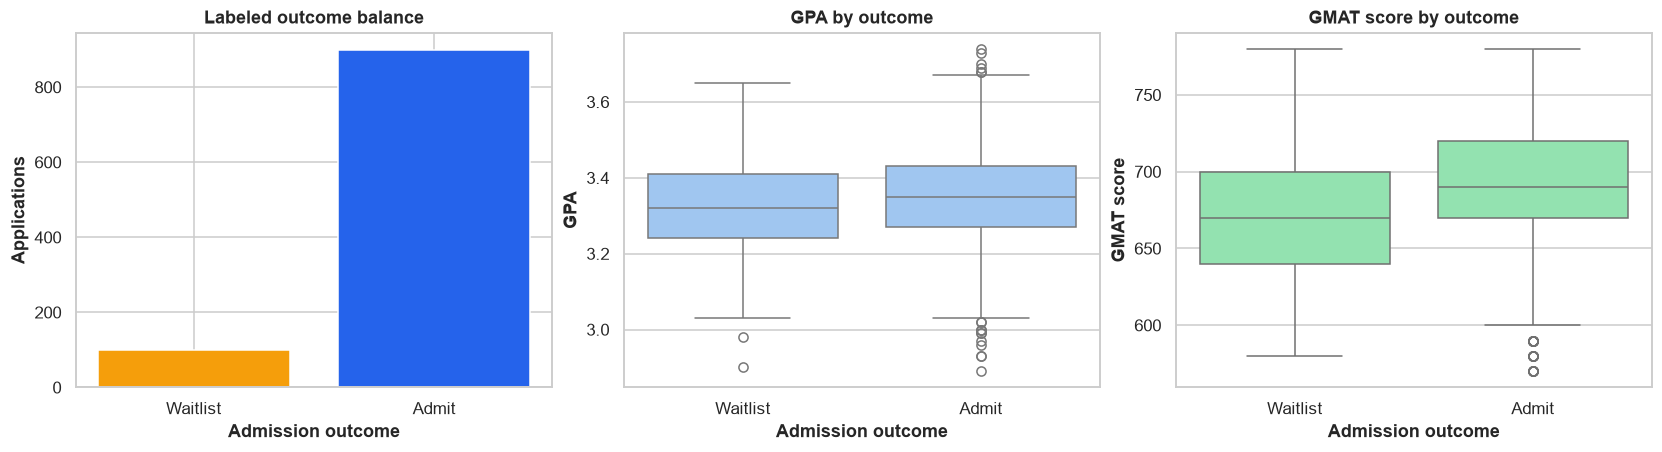

In [4]:
display(
    DualFormatTable(
        labeled[NUMERIC_FEATURES]
        .describe()
        .T[["count", "mean", "std", "min", "max"]]
        .reset_index(names="feature")
        .round(4)
    )
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
counts = labeled["admission"].value_counts().reindex(LABEL_ORDER)
axes[0].bar(counts.index, counts.values, color=["#f59e0b", "#2563eb"])
axes[0].set_title("Labeled outcome balance")
axes[0].set_xlabel("Admission outcome")
axes[0].set_ylabel("Applications")

sns.boxplot(
    data=labeled, x="admission", y="gpa", order=LABEL_ORDER, color="#93c5fd", ax=axes[1]
)
axes[1].set_title("GPA by outcome")
axes[1].set_xlabel("Admission outcome")
axes[1].set_ylabel("GPA")

sns.boxplot(
    data=labeled,
    x="admission",
    y="gmat",
    order=LABEL_ORDER,
    color="#86efac",
    ax=axes[2],
)
axes[2].set_title("GMAT score by outcome")
axes[2].set_xlabel("Admission outcome")
axes[2].set_ylabel("GMAT score")

display(fig)
plt.close(fig)

## 3. Holdout split and preprocessing

The 1,000 labeled applications are split into 80% training and 20% test data with stratification. The imputer and one-hot encoder are fitted inside the pipeline on training data only, which prevents test-set information from entering model fitting.

Because the target is imbalanced (`900 Admit` versus `100 Waitlist`), the decision tree uses `class_weight='balanced'`. This gives the minority Waitlist class more influence during fitting.

In [5]:
X = labeled[FEATURE_COLUMNS].copy()
y = labeled["admit"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

assert len(X_train) == 800 and len(X_test) == 200
assert y_train.value_counts().to_dict() == {1: 720, 0: 80}
assert y_test.value_counts().to_dict() == {1: 180, 0: 20}

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

tree_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Raw predictor columns: {X.shape[1]}")
print(f'Numeric predictor columns: {len(NUMERIC_FEATURES)}')
print(f'Categorical predictor columns: {len(CATEGORICAL_FEATURES)}')

Training rows: 800
Test rows: 200
Raw predictor columns: 8
Numeric predictor columns: 3
Categorical predictor columns: 5


## 4. Train the decision tree

A decision tree recursively chooses splits that make the resulting groups more pure. `max_depth=8` and `min_samples_leaf=20` constrain the tree so that it does not create very small terminal groups.

In [6]:
tree_pipeline.fit(X_train, y_train)
tree = tree_pipeline.named_steps["model"]
fitted_feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()

assert tree.n_features_in_ == len(fitted_feature_names)
assert tree.get_depth() <= 8
assert tree.tree_.n_leaves >= 2

print(f"Fitted tree depth: {tree.get_depth()}")
print(f"Fitted tree leaves: {tree.get_n_leaves()}")
print(f"Fitted transformed features: {len(fitted_feature_names)}")

Fitted tree depth: 8
Fitted tree leaves: 24
Fitted transformed features: 29


## 5. Plot the decision tree

The fitted tree can contain several levels. The visualization below limits the display to the first three levels so the main split logic remains readable; the model used for evaluation keeps its full fitted depth.

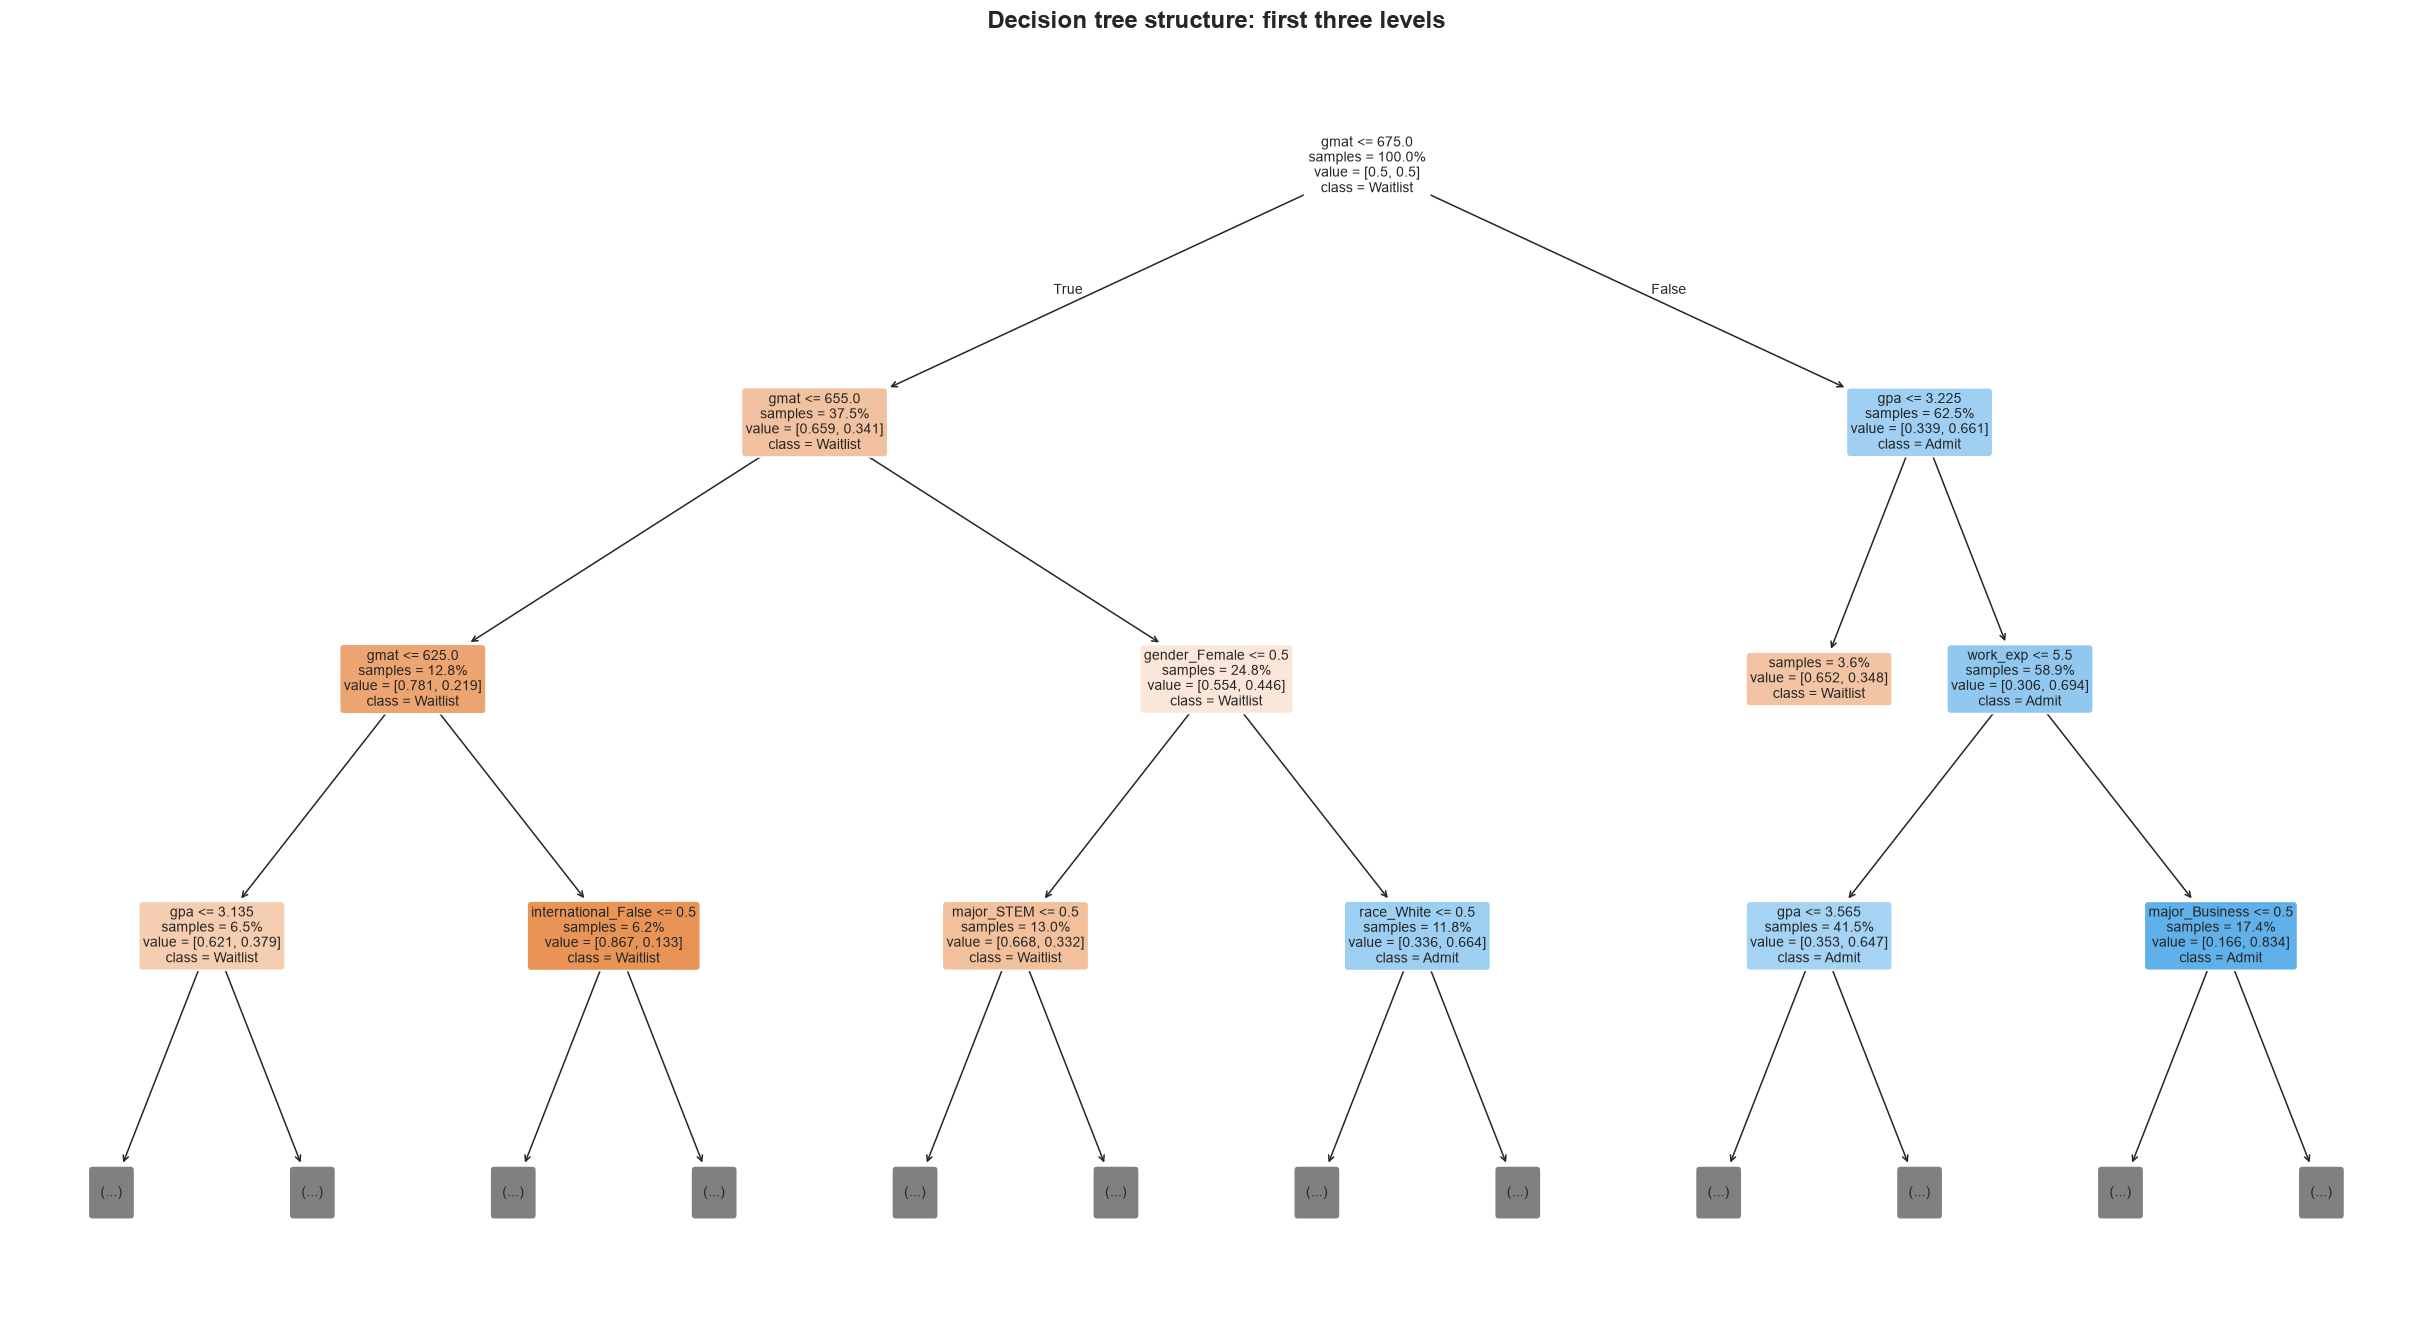

Saved tree visualization to outputs/decision_tree_structure.png.


In [7]:
TREE_FIGURE_PATH = OUTPUT_DIR / "decision_tree_structure.png"
fig, ax = plt.subplots(figsize=(22, 12), constrained_layout=True)
plot_tree(
    tree,
    feature_names=fitted_feature_names,
    class_names=LABEL_ORDER,
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    "Decision tree structure: first three levels", fontsize=16, fontweight="bold"
)
fig.savefig(TREE_FIGURE_PATH, dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved tree visualization to {TREE_FIGURE_PATH}.")

## 6. Variable importance

The tree's impurity-based importance scores sum to one. A larger score means that a transformed feature contributed more to the tree's impurity reductions. This is a model-specific association, not a causal effect.

In [8]:
importance_table = (
    pd.DataFrame(
        {
            "feature": fitted_feature_names,
            "importance": tree.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

assert np.isclose(importance_table["importance"].sum(), 1.0)
display(DualFormatTable(importance_table.head(15).round(4)))

feature,importance
gmat,0.4834
gpa,0.1952
race_White,0.0913
gender_Female,0.0734
international_False,0.0681
work_exp,0.0325
major_STEM,0.0230
major_Business,0.0172
major_Humanities,0.0160
work_industry_Health Care,0.0000


## 7. Prediction on the held-out test set

The default classification threshold is 0.5. The probability helper explicitly selects the probability column for `Admit = 1`, so the calculation remains correct even if a classifier changes class-column order.

In [9]:
def admit_probability(estimator: Pipeline, features: pd.DataFrame) -> np.ndarray:
    """Return P(Admit) from a fitted pipeline."""

    classifier = estimator.named_steps["model"]
    admit_column = int(np.flatnonzero(classifier.classes_ == 1)[0])
    return estimator.predict_proba(features)[:, admit_column]


y_pred_class = tree_pipeline.predict(X_test)
y_pred_prob = admit_probability(tree_pipeline, X_test)

assert y_pred_class.shape == (len(X_test),)
assert y_pred_prob.shape == (len(X_test),)
assert np.isfinite(y_pred_prob).all()
assert np.logical_and(y_pred_prob >= 0, y_pred_prob <= 1).all()

prediction_preview = pd.DataFrame(
    {
        "actual": np.where(y_test.to_numpy() == 1, "Admit", "Waitlist"),
        "predicted": np.where(y_pred_class == 1, "Admit", "Waitlist"),
        "admit_probability": y_pred_prob,
    },
    index=X_test.index,
)
display(DualFormatTable(prediction_preview.head(10).round(4)))

actual,predicted,admit_probability
Admit,Admit,1.0000
Waitlist,Admit,0.6786
Admit,Admit,0.6786
Admit,Admit,1.0000
Waitlist,Admit,0.7955
Admit,Admit,1.0000
Admit,Waitlist,0.2059
Admit,Admit,1.0000
Admit,Admit,0.7955
Admit,Admit,0.7692


## 8. Confusion matrix and classification report

Accuracy alone can hide poor Waitlist detection because Admit is the majority class. The report includes precision, recall, and F1 for both classes, while balanced accuracy gives each class equal weight.

In [10]:
confusion = confusion_matrix(y_true=y_test, y_pred=y_pred_class, labels=[0, 1])
confusion_table = pd.DataFrame(
    confusion,
    index=pd.Index([f"Actual {label}" for label in LABEL_ORDER]),
    columns=pd.Index([f"Predicted {label}" for label in LABEL_ORDER]),
)
display(DualFormatTable(confusion_table.reset_index(names="actual_class")))

report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_class,
        labels=[0, 1],
        target_names=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )
).T
report.index.name = "class"
display(DualFormatTable(report.reset_index().round(4)))

tree_metrics = pd.DataFrame(
    {
        "metric": [
            "Accuracy",
            "Balanced accuracy",
            "Admit precision",
            "Admit recall",
            "Admit F1",
            "Waitlist recall",
            "ROC AUC",
        ],
        "value": [
            accuracy_score(y_test, y_pred_class),
            balanced_accuracy_score(y_test, y_pred_class),
            precision_score(y_test, y_pred_class, pos_label=1, zero_division=0),
            recall_score(y_test, y_pred_class, pos_label=1, zero_division=0),
            f1_score(y_test, y_pred_class, pos_label=1, zero_division=0),
            recall_score(y_test, y_pred_class, pos_label=0, zero_division=0),
            roc_auc_score(y_test, y_pred_prob),
        ],
    }
)
assert tree_metrics["value"].between(0, 1).all()
display(DualFormatTable(tree_metrics.round(4)))

actual_class,Predicted Waitlist,Predicted Admit
Actual Waitlist,5,15
Actual Admit,66,114


class,precision,recall,f1-score,support
Waitlist,0.0704,0.2500,0.1099,20.0000
Admit,0.8837,0.6333,0.7379,180.0000
accuracy,0.5950,0.5950,0.5950,0.5950
macro avg,0.4771,0.4417,0.4239,200.0000
weighted avg,0.8024,0.5950,0.6751,200.0000


metric,value
Accuracy,0.5950
Balanced accuracy,0.4417
Admit precision,0.8837
Admit recall,0.6333
Admit F1,0.7379
Waitlist recall,0.2500
ROC AUC,0.4479


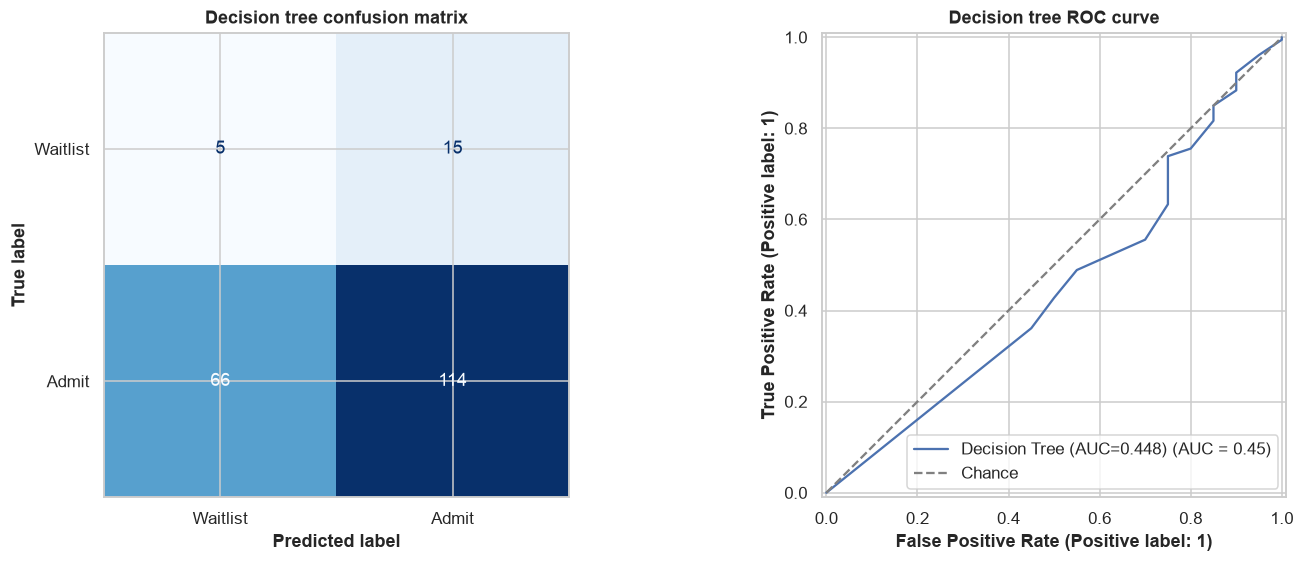

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_class,
    labels=[0, 1],
    display_labels=LABEL_ORDER,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Decision tree confusion matrix")

roc_auc = roc_auc_score(y_test, y_pred_prob)
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_prob,
    name=f"Decision Tree (AUC={roc_auc:.3f})",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Chance")
axes[1].set_title("Decision tree ROC curve")
axes[1].legend(loc="lower right")

display(fig)
plt.close(fig)

## 9. Score the unlabeled applications

The input contains 5,194 applications without observed outcomes. The trained tree scores them using the same preprocessing learned from the labeled training data. These predictions have no ground-truth evaluation in this file.

In [12]:
X_unlabeled = unlabeled[FEATURE_COLUMNS].copy()
unlabeled_predictions = unlabeled[["application_id"]].copy()
unlabeled_class = tree_pipeline.predict(X_unlabeled)
unlabeled_probability = admit_probability(tree_pipeline, X_unlabeled)

unlabeled_predictions["prediction"] = np.where(
    unlabeled_class == 1,
    "Admit",
    "Waitlist",
)
unlabeled_predictions["admit_probability"] = unlabeled_probability
unlabeled_predictions["model"] = "Decision Tree"

TREE_OUTPUT_PATH = OUTPUT_DIR / "MBA_admission_tree_predictions.csv"
unlabeled_predictions.to_csv(TREE_OUTPUT_PATH, index=False)

assert len(unlabeled_predictions) == len(unlabeled) == 5194
assert unlabeled_predictions["prediction"].isin(LABEL_ORDER).all()
assert unlabeled_predictions["admit_probability"].between(0, 1).all()
assert TREE_OUTPUT_PATH.exists()

display(DualFormatTable(unlabeled_predictions.head(10).round(4)))
prediction_counts = (
    unlabeled_predictions["prediction"]
    .value_counts()
    .reindex(LABEL_ORDER, fill_value=0)
    .rename_axis("prediction")
    .reset_index(name="count")
)
display(DualFormatTable(prediction_counts))
print(f"Saved {len(unlabeled_predictions):,} predictions to {TREE_OUTPUT_PATH}.")

application_id,prediction,admit_probability,model
2,Admit,0.6786,Decision Tree
4,Admit,1.0000,Decision Tree
5,Waitlist,0.4375,Decision Tree
6,Waitlist,0.4375,Decision Tree
8,Waitlist,0.2800,Decision Tree
9,Waitlist,0.4375,Decision Tree
10,Waitlist,0.3793,Decision Tree
11,Waitlist,0.3077,Decision Tree
12,Waitlist,0.3077,Decision Tree
14,Admit,0.7955,Decision Tree


prediction,count
Waitlist,4177
Admit,1017


Saved 5,194 predictions to outputs/MBA_admission_tree_predictions.csv.


## Conclusion

This analysis trains and evaluates a regularized, class-balanced decision tree for the binary outcome `Admit` versus `Waitlist`. The model is evaluated on the untouched stratified test set with ordinary and class-balanced metrics.

The predictions for rows without observed outcomes are model estimates, not confirmed admissions decisions. They should be reviewed with domain policy, fairness checks, and a future labeled evaluation set before operational use.